In [ ]:
# !pip install deepxde -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.3 MB/s eta 0:00:0000:01


Set the default float type to float64
--- Training with Adam ---
Compiling model...
'compile' took 2.929375 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [7.81e-02, 7.18e-01, 1.60e-01]    [7.81e-02, 7.18e-01, 1.60e-01]    []  


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [2.55e-03, 3.39e-04, 6.28e-04]    [2.55e-03, 3.39e-04, 6.28e-04]    []  
2000      [2.13e-04, 5.21e-05, 1.92e-04]    [2.13e-04, 5.21e-05, 1.92e-04]    []  
3000      [9.62e-04, 1.60e-03, 8.15e-04]    [9.62e-04, 1.60e-03, 8.15e-04]    []  
4000      [5.82e-04, 5.43e-04, 2.64e-04]    [5.82e-04, 5.43e-04, 2.64e-04]    []  
5000      [2.27e-04, 1.92e-04, 7.96e-05]    [2.27e-04, 1.92e-04, 7.96e-05]    []  
6000      [6.90e-05, 1.19e-05, 7.26e-06]    [6.90e-05, 1.19e-05, 7.26e-06]    []  
7000      [6.00e-05, 4.53e-05, 2.19e-05]    [6.00e-05, 4.53e-05, 2.19e-05]    []  
8000      [3.57e-05, 9.49e-06, 4.25e-06]    [3.57e-05, 9.49e-06, 4.25e-06]    []  
9000      [2.76e-05, 7.43e-06, 4.96e-06]    [2.76e-05, 7.43e-06, 4.96e-06]    []  
10000     [2.26e-05, 4.52e-06, 4.33e-06]    [2.26e-05, 4.52e-06, 4.33e-06]    []  
11000     [3.36e-05, 1.34e-05, 1.75e-05]    [3.36e-05, 1.34e-05, 1.75e-05]    []  
12000     [1.40e-05, 2.42e-06, 3.86e-06]    [1.40e-05, 2.42e-06, 3.86e-06]    []  
1300

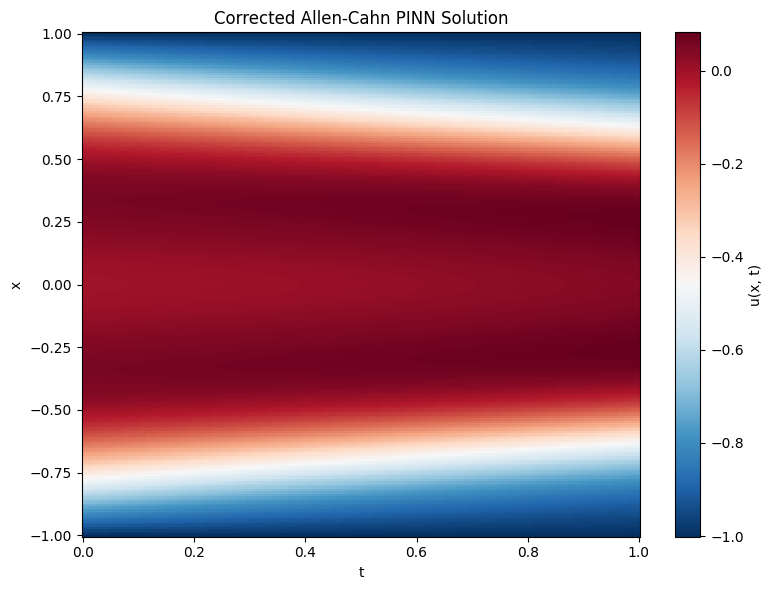

In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import torch

dde.config.set_default_float("float64")


time = dde.geometry.TimeDomain(0, 1)
space = dde.geometry.Interval(-1, 1)
geom = dde.geometry.GeometryXTime(space, time)



epsilon_sq = 0.01  # Increased slightly from 0.0001 to help the PINN converge initially

def pde(x, u):
    du_t = dde.grad.jacobian(u, x, i=0, j=1)
    du_xx = dde.grad.hessian(u, x, i=0, j=0)
    return du_t - epsilon_sq * du_xx - u + u**3

bc = dde.icbc.DirichletBC(
    geom,
    lambda x: -1.0,  # Matches the IC at x = -1 and x = 1
    lambda _, on_boundary: on_boundary
)

ic = dde.icbc.IC(
    geom,
    lambda x: x[:, 0:1]**2 * np.cos(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

data = dde.data.TimePDE(
    geom, pde, [bc, ic],
    num_domain=10000,
    num_boundary=1000,
    num_initial=1000,
)

net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)


print("--- Training with Adam ---")
model.compile("adam", lr=0.001)
model.train(iterations=15000)


print("--- Refining with L-BFGS ---")
model.compile("L-BFGS")
losshistory, train_state = model.train()

x_vals = np.linspace(-1, 1, 200)
t_vals = np.linspace(0, 1, 200)
X, T = np.meshgrid(x_vals, t_vals)
x_test = np.column_stack([X.flatten(), T.flatten()])

prediction = model.predict(x_test)
U = prediction[:, 0].reshape(200, 200)

plt.figure(figsize=(8, 6))
plt.pcolormesh(T, X, U, shading='auto', cmap="RdBu_r")
plt.colorbar(label="u(x, t)")
plt.ylabel("x")
plt.xlabel("t")
plt.title("Corrected Allen-Cahn PINN Solution")
plt.tight_layout()
plt.show()